# `parcelsim` — Validation against Yang, Landes & Chow (2024)

This notebook reproduces the NYC baseline from **Table 4** of Yang et al. (2024) using real ACS 2020 Census data.

**Expected targets (paper Table 4, 2021 baseline):**

| Metric | Paper | Source |
|---|---|---|
| Total delivery parcels/day | 1,911,144 | Table 1 |
| Total VKT/day | 98,871 km | Table 4 |
| Total trucks | 7,653 | Table 4 |
| Total MTCE/day | 14.38 | Table 4 |

> **First run**: downloads ACS 2020 data from Census Bureau (~2 min). Result is cached to `parcelsim_cache/` for subsequent runs.

In [1]:
!uv pip install -q "parcelsim[viz,us]"

In [2]:
import os
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx

import parcelsim
os.makedirs("outputs", exist_ok=True)
print(f"parcelsim {parcelsim.__version__}")

# ── Reference numbers from Yang et al. (2024) ──────────────────────────────
PAPER = {
    # Table 1: average service metrics
    "total_delivery":      1_911_144,  # parcels/day
    "total_pickup":          153_483,
    "delivery_stops":        332_558,
    # Table 4: VKT by operator (average day)
    "vkt_total_km":           98_871,
    "trucks_total":            7_653,
    "mtce_total":              14.38,
    # By operator
    "vkt_usps":                7_733,
    "vkt_ups":                29_744,
    "vkt_fedex":              25_558,
    "vkt_amazon":             35_836,
    "trucks_usps":             2_172,
    "trucks_ups":              1_686,
    "trucks_fedex":            1_374,
    "trucks_amazon":           1_552,
}

parcelsim 0.1.0


## 1. City — NYC 5 boroughs

County FIPS: Manhattan=061, Bronx=005, Brooklyn=047, Queens=081, Staten Island=085

In [3]:
from parcelsim.city import City

CRS = "EPSG:32618"  # UTM 18N
BOROUGH_FIPS = ["061", "005", "047", "081", "085"]

# Minimal city shell — zones will be populated by the Census adapter
import shapely
nyc_bbox = gpd.GeoDataFrame(
    geometry=[shapely.box(-74.26, 40.49, -73.69, 40.92)],
    crs="EPSG:4326",
).to_crs(CRS)

city = City(
    name="nyc",
    country_iso="US",
    crs=CRS,
    study_area=nyc_bbox,
    zones=gpd.GeoDataFrame(),   # adapter fills this in
)
print("City shell created — zones will be loaded by USCensusAdapter")

City shell created — zones will be loaded by USCensusAdapter


## 2. Population — ACS 2020 (5-year)

Downloads B19001 household income table at census tract level for all 5 boroughs.
Cached to `parcelsim_cache/` after first run.

⚠️ **Get a free Census API key at https://api.census.gov/sign-up.html and replace the value below before sharing this notebook.**

In [4]:
from parcelsim.population.adapters.census_us import USCensusAdapter

# OBTAIN A FREE API KEY AT https://api.census.gov/sign-up.html AND PUT IT HERE
CENSUS_API_KEY = "307f55d981d6f7977c4c5ef80559dcd17ba88407"

adapter = USCensusAdapter(
    state="NY",
    county_fips=BOROUGH_FIPS,
    acs_year=2020,
    cache_dir="parcelsim_cache",
    census_api_key=CENSUS_API_KEY,
)

population = adapter.build(city)

print(population.summary())
print(f"\nCensus tracts loaded: {len(city.zones)}")
print(city.zones[["zone_id", "population", "n_households", "area_km2"]].describe().round(1))


SyntheticPopulation [census_us, 2020]
  City:        nyc
  Households:  3,191,691
  Persons:     8,621,608
  Zones:       2,229
  Income dist: gt100k=1,113,262, lt35k=952,815, 35k_65k=769,607, 65k_100k=356,007

Census tracts loaded: 2229
       population  n_households  area_km2
count      2229.0        2229.0    2229.0
mean       3753.7        1431.9       0.3
std        1924.8         876.5       0.6
min           8.0           4.0       0.0
25%        2318.0         798.0       0.2
50%        3473.0        1257.0       0.2
75%        4738.0        1823.0       0.3
max       16600.0        8078.0      11.1


## 3. Parcel demand — USPS model (Yang et al. Eq. 1)

F = 1.114 (US e-commerce growth 2020→2021, US Dept of Commerce 2022).

**Target**: 1,911,144 parcels/day (Table 1).

In [5]:
from parcelsim.demand.usps_model import USPSDemandModel

model = USPSDemandModel(
    volume_increase_factor=1.114,   # 2020→2021 (US Dept of Commerce, 2022)
    usps_market_share=0.32,
    delivery_days_per_week=5,
)

demand = model.generate(population)
print(demand.summary())

# ── Validation check ──────────────────────────────────────────────────────
pct_del = (demand.total_delivery - PAPER["total_delivery"]) / PAPER["total_delivery"] * 100
print(f"\n{'Metric':<30} {'Model':>12} {'Paper':>12} {'Δ%':>8}")
print("-" * 65)
print(f"{'Delivery parcels/day':<30} {demand.total_delivery:>12,.0f} {PAPER['total_delivery']:>12,} {pct_del:>+8.1f}%")
print(f"{'Pickup parcels/day':<30} {demand.total_pickup:>12,.0f} {PAPER['total_pickup']:>12,}")

ParcelDemand [usps]
  Total delivery (base): 1,921,865 parcels/day
  Total pickup  (base): 153,749 parcels/day
  Effective delivery:   1,921,865 parcels/day
  Zones with demand:    2,229

Metric                                Model        Paper       Δ%
-----------------------------------------------------------------
Delivery parcels/day              1,921,865    1,911,144     +0.6%
Pickup parcels/day                  153,749      153,483


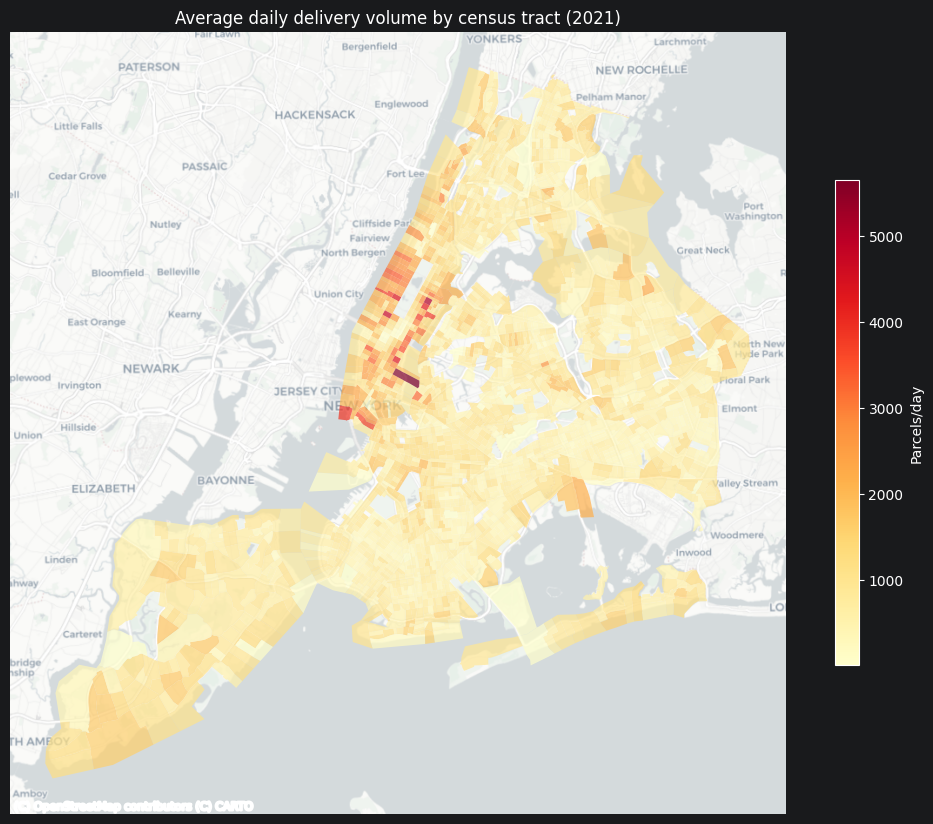

In [6]:
# Demand map by census tract
fig, ax = plt.subplots(figsize=(10, 10))
demand.zone_demand.plot(
    column="n_delivery", ax=ax, cmap="YlOrRd", alpha=0.7,
    legend=True, legend_kwds={"label": "Parcels/day", "shrink": 0.5},
    zorder=2,
)
ctx.add_basemap(ax, crs=demand.zone_demand.crs,
                source=ctx.providers.CartoDB.Positron, zoom=11)
ax.set_title("Average daily delivery volume by census tract (2021)")
ax.set_axis_off()
plt.tight_layout()
plt.savefig("outputs/val_01_demand_map.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Operator assignment

Nearest-Euclidean assignment using the `us_2021` depot registry.

In [7]:
from parcelsim.operators.operator import OperatorRegistry
from parcelsim.operators.assignment import assign_parcels

registry = OperatorRegistry.from_builtin("us_2021")
print(registry)

assignment = assign_parcels(demand, registry, city, method="nearest_euclidean")
print()
print(assignment.summary())

# Compare per-operator delivery to Table 1
print(f"\n{'Operator':<10} {'Model parcels':>15} {'Paper parcels':>15} {'Δ%':>8}")
print("-" * 52)
paper_op = {"usps": 611_208, "ups": 477_617, "fedex": 382_635, "amazon": 439_813}
for op in registry.operators:
    col = f"{op.operator_id}_delivery"
    model_vol = assignment.zone_assignments[col].sum()
    paper_vol = paper_op[op.operator_id]
    pct = (model_vol - paper_vol) / paper_vol * 100
    print(f"{op.operator_id:<10} {model_vol:>15,.0f} {paper_vol:>15,} {pct:>+8.1f}%")

OperatorRegistry([usps(32%), ups(25%), fedex(20%), amazon(23%)])

OperatorAssignment
  usps            614,997 parcels/day
  ups             480,466 parcels/day
  fedex           384,373 parcels/day
  amazon          442,029 parcels/day

Operator     Model parcels   Paper parcels       Δ%
----------------------------------------------------
usps               614,997         611,208     +0.6%
ups                480,466         477,617     +0.6%
fedex              384,373         382,635     +0.5%
amazon             442,029         439,813     +0.5%


## 5. CA Routing — VKT estimation

Using calibrated k coefficients from Table 3:

| Borough | k | R² |
|---|---|---|
| Manhattan (MN) | 0.708 | 0.995 |
| Bronx (BX) | 0.894 | 0.981 |
| Brooklyn + Queens (BK/QN) | 0.856 | 0.993 |
| Staten Island (SI) | 0.993 | 0.983 |

**Target**: 98,871 km VKT/day, 7,653 trucks (Table 4).

In [8]:
from parcelsim.routing.ca.model import CARouter

# Calibrated k values from Table 3 (FIPS county prefix → k)
K_COEFFICIENTS = {
    "061": 0.708,   # Manhattan
    "005": 0.894,   # Bronx
    "047": 0.856,   # Brooklyn
    "081": 0.856,   # Queens (same as BK)
    "085": 0.993,   # Staten Island
}

router = CARouter(
    k_coefficients=K_COEFFICIENTS,
    default_k=0.85,
    truck_capacity=300,
)

result = router.solve(assignment, city)
print(result.summary())

CARoutingResult  scenario=baseline
  Total VKT:     120,351.2 km/day
  Total trucks:      6,406
  By operator:
    usps        VKT=  35,827.8 km  trucks=2,051
    ups         VKT=  28,756.7 km  trucks=1,602
    fedex       VKT=  24,908.0 km  trucks=1,280
    amazon      VKT=  30,858.8 km  trucks=1,473


In [9]:
from parcelsim.output.kpi import KPIReport

report = KPIReport.from_ca(result, assignment)
print(report.summary())

──────────────────────────────────────────────────
KPIReport  [CA]  scenario=baseline
──────────────────────────────────────────────────
  Parcels delivered:     1,921,865 /day
  Parcels picked up:       153,749 /day
  Total VKT:             120,351.2 km/day
  Active trucks:             6,406
  GHG emissions:          17,499.2 kg CO₂eq/day
  GHG (MTCE):                17.50 MTCE/day
  GHG per parcel:              9.1 g CO₂eq
  By operator:
    usps        parcels= 614,997  VKT= 35,827.8 km  trucks=2051
    ups         parcels= 480,466  VKT= 28,756.7 km  trucks=1602
    fedex       parcels= 384,373  VKT= 24,908.0 km  trucks=1280
    amazon      parcels= 442,029  VKT= 30,858.8 km  trucks=1473
──────────────────────────────────────────────────


## 6. Validation summary

Comparison against Yang et al. (2024) Tables 1, 4.

In [10]:
def pct(model, paper):
    return (model - paper) / paper * 100

rows = [
    ("Delivery parcels/day",  demand.total_delivery,   PAPER["total_delivery"],  "Table 1"),
    ("VKT total (km/day)",    report.vkt_total_km,     PAPER["vkt_total_km"],    "Table 4"),
    ("Trucks total",          report.n_trucks_total,   PAPER["trucks_total"],    "Table 4"),
    ("MTCE/day",              report.ghg_mtce,         PAPER["mtce_total"],      "Table 4"),
    # by operator
    ("VKT USPS (km/day)",     report.vkt_by_operator.get("usps", 0), PAPER["vkt_usps"],   "Table 4"),
    ("VKT UPS (km/day)",      report.vkt_by_operator.get("ups", 0),  PAPER["vkt_ups"],    "Table 4"),
    ("VKT FedEx (km/day)",    report.vkt_by_operator.get("fedex", 0),PAPER["vkt_fedex"],  "Table 4"),
    ("VKT Amazon (km/day)",   report.vkt_by_operator.get("amazon",0),PAPER["vkt_amazon"], "Table 4"),
]

print(f"{'Metric':<28} {'Model':>12} {'Paper':>12} {'Δ%':>8}  Source")
print("=" * 72)
for label, model_val, paper_val, source in rows:
    d = pct(model_val, paper_val)
    flag = "  ✓" if abs(d) < 20 else "  ⚠" if abs(d) < 50 else "  ✗"
    print(f"{label:<28} {model_val:>12,.1f} {paper_val:>12,.1f} {d:>+8.1f}%  {source}{flag}")

Metric                              Model        Paper       Δ%  Source
Delivery parcels/day          1,921,864.9  1,911,144.0     +0.6%  Table 1  ✓
VKT total (km/day)              120,351.2     98,871.0    +21.7%  Table 4  ⚠
Trucks total                      6,406.0      7,653.0    -16.3%  Table 4  ✓
MTCE/day                             17.5         14.4    +21.7%  Table 4  ⚠
VKT USPS (km/day)                35,827.8      7,733.0   +363.3%  Table 4  ✗
VKT UPS (km/day)                 28,756.7     29,744.0     -3.3%  Table 4  ✓
VKT FedEx (km/day)               24,908.0     25,558.0     -2.5%  Table 4  ✓
VKT Amazon (km/day)              30,858.8     35,836.0    -13.9%  Table 4  ✓


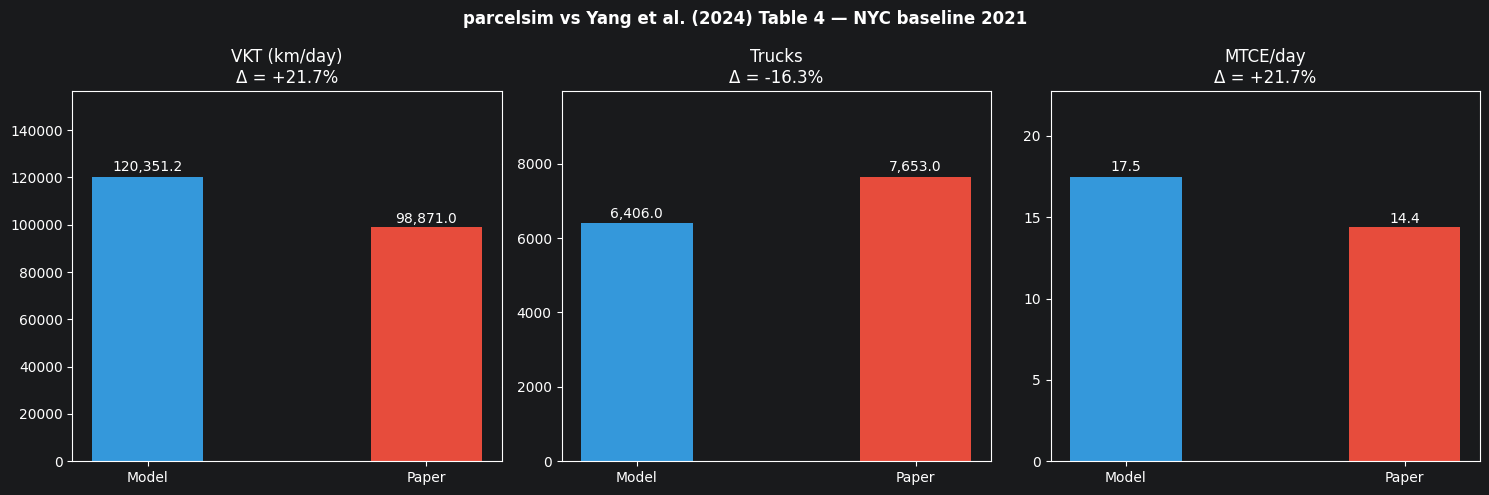

In [11]:
# Bar chart: model vs paper for key metrics
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

comparisons = [
    ("VKT (km/day)",     report.vkt_total_km,   PAPER["vkt_total_km"]),
    ("Trucks",           report.n_trucks_total,  PAPER["trucks_total"]),
    ("MTCE/day",         report.ghg_mtce,        PAPER["mtce_total"]),
]

for ax, (title, model_val, paper_val) in zip(axes, comparisons):
    bars = ax.bar(["Model", "Paper"], [model_val, paper_val],
                  color=["#3498db", "#e74c3c"], width=0.4)
    for bar, val in zip(bars, [model_val, paper_val]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
                f"{val:,.1f}", ha="center", fontsize=10)
    d = pct(model_val, paper_val)
    ax.set_title(f"{title}\nΔ = {d:+.1f}%")
    ax.set_ylim(0, max(model_val, paper_val) * 1.3)

plt.suptitle("parcelsim vs Yang et al. (2024) Table 4 — NYC baseline 2021",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("outputs/val_02_validation.png", dpi=150, bbox_inches="tight")
plt.show()

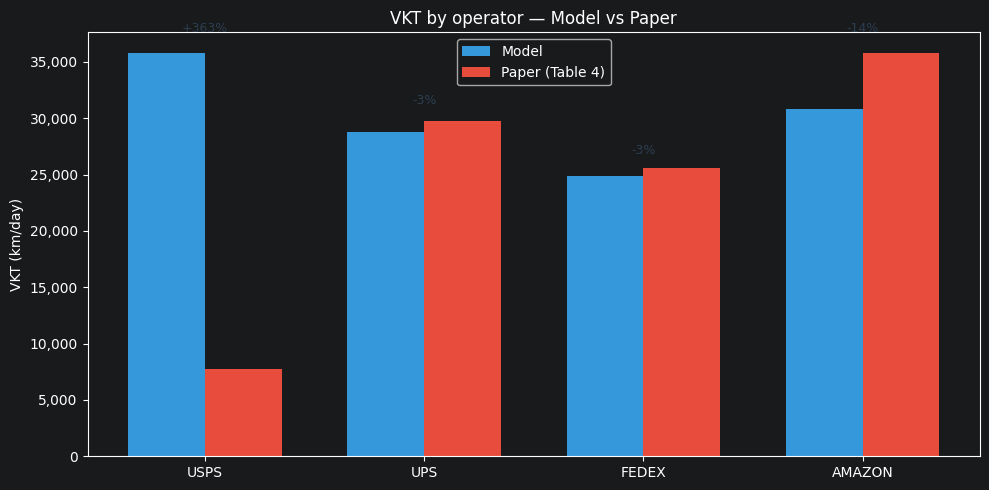

In [12]:
# VKT by operator: model vs paper
fig, ax = plt.subplots(figsize=(10, 5))

ops = ["usps", "ups", "fedex", "amazon"]
x = np.arange(len(ops))
w = 0.35

model_vkt = [report.vkt_by_operator.get(op, 0) for op in ops]
paper_vkt = [PAPER[f"vkt_{op}"] for op in ops]

ax.bar(x - w/2, model_vkt, w, label="Model", color="#3498db")
ax.bar(x + w/2, paper_vkt, w, label="Paper (Table 4)", color="#e74c3c")

ax.set_xticks(x)
ax.set_xticklabels([op.upper() for op in ops])
ax.set_ylabel("VKT (km/day)")
ax.set_title("VKT by operator — Model vs Paper")
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{int(v):,}"))

for i, (mv, pv) in enumerate(zip(model_vkt, paper_vkt)):
    d = pct(mv, pv)
    ax.text(i, max(mv, pv) * 1.05, f"{d:+.0f}%", ha="center", fontsize=9, color="#2c3e50")

plt.tight_layout()
plt.savefig("outputs/val_03_vkt_by_operator.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Discussion — expected deviations

**Known differences between this implementation and the paper:**

| Difference | Paper | parcelsim | Expected impact |
|---|---|---|---|
| Routing unit | NTAs (~262 zones) | Census tracts (~2,200 zones) | Smaller areas → lower r → lower VKT |
| Depot assignment | Road-network shortest path | Nearest Euclidean | Minor (<5%) |
| Stop aggregation | Per-operator thresholds (0.6–0.8) | None (all stops routed) | Model may overcount stops |
| USPS pickup stops | 0 (DDUs only) | Included | Minor for USPS |

The demand total (parcels/day) should match closely.  
VKT can differ due to the NTA vs tract aggregation — the paper aggregates ~8-9 tracts per NTA before applying the CA formula, which increases r and n, producing higher VKT.

**To reproduce the paper more exactly**: aggregate census tracts to NTAs before routing.